# CH 5 - 6 : WHAT DO CONFIDENCE INTERVALS TELL US?

## Objectif pédagogique

Ce notebook transforme le concept d'**intervalle de confiance** en outil concret pour analyser une règle de trading.

L'idée centrale : un backtest ne donne jamais une vérité exacte sur le futur. Il donne une **estimation**, entourée d'une **marge d'erreur**.

Dans ce notebook, on va voir :

1. pourquoi une moyenne de backtest seule est insuffisante ;
2. comment construire un intervalle de confiance autour d'une performance moyenne ;
3. comment interpréter la borne basse dans une décision de trading ;
4. pourquoi plus de trades ou moins de volatilité rendent l'intervalle plus précis.

## 1. Intuition simple

Une estimation ponctuelle dit :

> Ma stratégie gagne en moyenne 0,08 % par trade.

Mais cette phrase est incomplète. Elle ne dit pas si cette moyenne est stable, fragile, ou presque impossible à distinguer du bruit.

L'intervalle de confiance ajoute la question importante :

> Avec l'incertitude du backtest, quelle fourchette réaliste peut contenir la vraie performance future ?

En trading EBTA, c'est fondamental : on ne veut pas seulement savoir si le backtest est positif. On veut savoir si la performance reste crédible **après avoir intégré l'erreur d'échantillonnage**.

## 2. Formule de base

Pour une moyenne de rendements, un intervalle de confiance classique peut s'écrire :

$$
IC = \bar{x} \pm z \times \frac{s}{\sqrt{n}}
$$

Avec :

- $\bar{x}$ : moyenne observée du backtest ;
- $s$ : volatilité des rendements ;
- $n$ : nombre d'observations ou de trades ;
- $\frac{s}{\sqrt{n}}$ : erreur standard ;
- $z$ : coefficient lié au niveau de confiance.

Pour un intervalle à 95 %, on utilise souvent $z \approx 1.96$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulation d'une stratégie de trading
# Hypothèse : 250 trades, rendement moyen réel faible mais positif, volatilité élevée
n_trades = 250
true_mean = 0.0008      # 0,08 % par trade
volatility = 0.01       # 1 % de volatilité par trade

returns = np.random.normal(loc=true_mean, scale=volatility, size=n_trades)

df = pd.DataFrame({
    "trade": np.arange(1, n_trades + 1),
    "return": returns,
    "equity_curve": (1 + returns).cumprod()
})

df.head()

,trade,return,equity_curve
0,1,0.005767,1.005767
1,2,-0.000583,1.005181
2,3,0.007277,1.012496
3,4,0.016030,1.028726
4,5,-0.001542,1.027141


## 3. Estimation ponctuelle : le chiffre séduisant mais incomplet

Calculons d'abord la moyenne du backtest. C'est l'estimation ponctuelle.

In [2]:
mean_return = df["return"].mean()
std_return = df["return"].std(ddof=1)
annualized_mean = mean_return * n_trades

print(f"Moyenne par trade : {mean_return:.4%}")
print(f"Volatilité par trade : {std_return:.4%}")
print(f"Performance moyenne annualisée approximative : {annualized_mean:.2%}")

Moyenne par trade : 0.0776%
Volatilité par trade : 0.9661%
Performance moyenne annualisée approximative : 19.39%


Cette moyenne est utile, mais elle peut être trompeuse. Deux stratégies peuvent avoir la même moyenne, mais pas la même fiabilité statistique.

Ce qui manque ici, c'est la **marge d'erreur**.

## 4. Construction d'un intervalle de confiance à 95 %

On calcule maintenant l'erreur standard, puis les bornes basse et haute de l'intervalle.

In [3]:
z_95 = 1.96
standard_error = std_return / np.sqrt(n_trades)
margin_error = z_95 * standard_error

ci_low = mean_return - margin_error
ci_high = mean_return + margin_error

print(f"Erreur standard : {standard_error:.4%}")
print(f"Marge d'erreur 95 % : ±{margin_error:.4%}")
print(f"IC 95 % par trade : [{ci_low:.4%}, {ci_high:.4%}]")
print(f"IC 95 % annualisé approx. : [{ci_low*n_trades:.2%}, {ci_high*n_trades:.2%}]")

Erreur standard : 0.0611%
Marge d'erreur 95 % : ±0.1198%
IC 95 % par trade : [-0.0422%, 0.1973%]
IC 95 % annualisé approx. : [-10.54%, 49.33%]


## 5. Interprétation trading

La borne basse est souvent plus importante que la moyenne.

Pourquoi ?

Parce qu'elle répond à une question de prudence :

> Même en tenant compte de l'incertitude, est-ce que ma stratégie reste positive ?

Si la borne basse est négative, cela ne veut pas dire que la stratégie est forcément mauvaise. Mais cela signifie que le backtest n'est pas encore assez solide pour exclure une performance réelle nulle ou perdante.

In [4]:
if ci_low > 0:
    verdict = "La borne basse est positive : le backtest est statistiquement plus robuste."
elif ci_high < 0:
    verdict = "Même la borne haute est négative : la stratégie semble défavorable."
else:
    verdict = "L'intervalle traverse zéro : la stratégie reste statistiquement fragile."

print(verdict)

L'intervalle traverse zéro : la stratégie reste statistiquement fragile.


## 6. Visualiser l'incertitude

Le graphique suivant montre la moyenne observée et son intervalle de confiance.

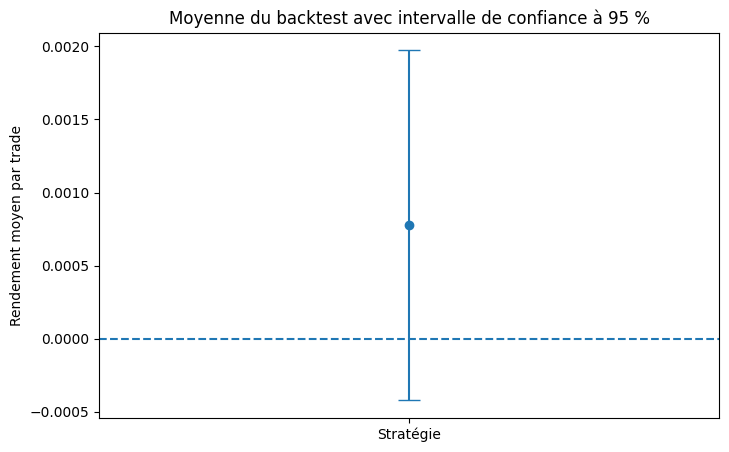

In [5]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    x=["Stratégie"],
    y=[mean_return],
    yerr=[[mean_return - ci_low], [ci_high - mean_return]],
    fmt="o",
    capsize=8
)
plt.axhline(0, linestyle="--")
plt.title("Moyenne du backtest avec intervalle de confiance à 95 %")
plt.ylabel("Rendement moyen par trade")
plt.show()

## 7. Pourquoi augmenter le nombre de trades rétrécit l'intervalle ?

L'erreur standard est :

$$
\frac{s}{\sqrt{n}}
$$

Donc, quand $n$ augmente, l'incertitude diminue. Mais elle diminue avec la racine carrée : il faut beaucoup plus de trades pour gagner vraiment en précision.

In [6]:
sample_sizes = np.array([30, 50, 100, 250, 500, 1000, 2000])
errors = z_95 * std_return / np.sqrt(sample_sizes)

precision_df = pd.DataFrame({
    "Nombre de trades": sample_sizes,
    "Marge d'erreur 95 % par trade": errors,
    "Largeur totale de l'IC": 2 * errors
})

precision_df

,Nombre de trades,Marge d'erreur 95 % par trade,Largeur totale de l'IC
0,30,0.003457,0.006914
1,50,0.002678,0.005356
2,100,0.001893,0.003787
3,250,0.001198,0.002395
4,500,0.000847,0.001694
5,1000,0.000599,0.001198
6,2000,0.000423,0.000847


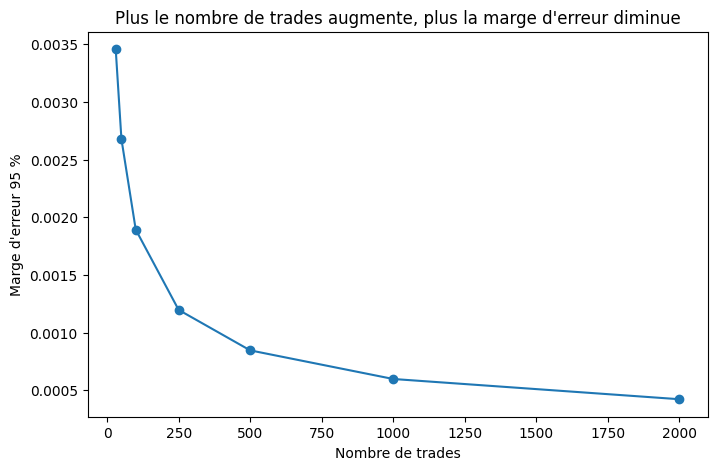

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, errors, marker="o")
plt.title("Plus le nombre de trades augmente, plus la marge d'erreur diminue")
plt.xlabel("Nombre de trades")
plt.ylabel("Marge d'erreur 95 %")
plt.show()

## 8. Exemple pratique : comparer deux stratégies

Imaginons deux stratégies :

- Stratégie A : moyenne plus élevée, mais très volatile ;
- Stratégie B : moyenne plus faible, mais plus stable.

La meilleure décision n'est pas toujours celle qui a la moyenne la plus haute. Il faut regarder la borne basse de l'intervalle.

In [8]:
strategies = pd.DataFrame({
    "strategie": ["A - Forte moyenne, forte volatilité", "B - Moyenne plus faible, plus stable"],
    "mean": [0.0012, 0.0007],
    "std": [0.018, 0.006],
    "n": [250, 250]
})

strategies["standard_error"] = strategies["std"] / np.sqrt(strategies["n"])
strategies["ci_low"] = strategies["mean"] - z_95 * strategies["standard_error"]
strategies["ci_high"] = strategies["mean"] + z_95 * strategies["standard_error"]
strategies["annualized_mean"] = strategies["mean"] * 250
strategies["annualized_ci_low"] = strategies["ci_low"] * 250
strategies["annualized_ci_high"] = strategies["ci_high"] * 250

strategies[[
    "strategie", "annualized_mean", "annualized_ci_low", "annualized_ci_high"
]]

,strategie,annualized_mean,annualized_ci_low,annualized_ci_high
0,"A - Forte moyenne, forte volatilité",0.300,-0.257826,0.857826
1,"B - Moyenne plus faible, plus stable",0.175,-0.010942,0.360942


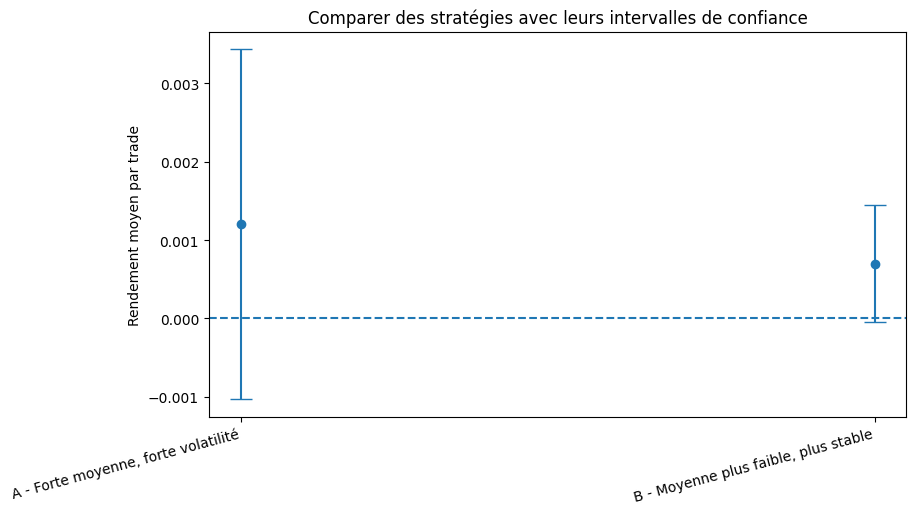

In [9]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    x=strategies["strategie"],
    y=strategies["mean"],
    yerr=[strategies["mean"] - strategies["ci_low"], strategies["ci_high"] - strategies["mean"]],
    fmt="o",
    capsize=8
)
plt.axhline(0, linestyle="--")
plt.title("Comparer des stratégies avec leurs intervalles de confiance")
plt.ylabel("Rendement moyen par trade")
plt.xticks(rotation=15, ha="right")
plt.show()

## 9. Lecture EBTA

Dans une approche EBTA, l'intervalle de confiance est un outil de discipline.

Il empêche de dire :

> Mon backtest gagne 15 %, donc ma stratégie vaut 15 %.

Il force plutôt à dire :

> Mon backtest estime une performance moyenne, mais la vraie performance future peut raisonnablement se situer dans une fourchette.

Cette nuance change tout. Elle protège contre l'excès de confiance, le surdimensionnement de position, et les conclusions trop rapides après un backtest positif.

## 10. Mini-fonction réutilisable

Voici une fonction simple pour calculer rapidement un intervalle de confiance sur une série de rendements.

In [10]:
def confidence_interval_mean(returns, confidence=0.95):
    """
    Calcule un intervalle de confiance approximatif pour la moyenne d'une série de rendements.

    Paramètres
    ----------
    returns : array-like
        Série de rendements de trades ou de jours.
    confidence : float
        Niveau de confiance. Support simple : 0.90, 0.95, 0.99.
    """
    z_values = {
        0.90: 1.645,
        0.95: 1.96,
        0.99: 2.576
    }

    if confidence not in z_values:
        raise ValueError("Utilise 0.90, 0.95 ou 0.99 pour cette fonction simple.")

    returns = np.asarray(returns)
    n = len(returns)
    mean = returns.mean()
    std = returns.std(ddof=1)
    se = std / np.sqrt(n)
    margin = z_values[confidence] * se

    return {
        "n": n,
        "mean": mean,
        "standard_error": se,
        "ci_low": mean - margin,
        "ci_high": mean + margin,
        "margin_error": margin
    }

result = confidence_interval_mean(df["return"], confidence=0.95)
result

{'n': 250,
 'mean': np.float64(0.0007757709587846937),
 'standard_error': np.float64(0.0006109860041713393),
 'ci_low': np.float64(-0.0004217616093911313),
 'ci_high': np.float64(0.0019733035269605187),
 'margin_error': np.float64(0.001197532568175825)}

## 11. À retenir absolument

- Une estimation ponctuelle donne un chiffre ; un intervalle de confiance donne un **cadre réaliste**.
- Plus l'échantillon est petit, plus l'intervalle est large.
- Plus la volatilité est forte, plus l'intervalle est large.
- Un niveau de confiance plus élevé donne un intervalle plus sûr, mais moins précis.
- En trading, la borne basse est cruciale : elle révèle la fragilité cachée d'une stratégie.

La vraie question n'est donc pas seulement :

> Combien la stratégie a gagné en backtest ?

Mais plutôt :

> Après incertitude statistique, que reste-t-il de cette performance ?

---

# Annexe — Source originale collée

### **CH 5 - 6 : WHAT DO CONFIDENCE INTERVALS TELL US?**

Voici l’analyse technique de l’utilité et de la signification des intervalles de confiance, l’outil qui permet de quantifier l’incertitude entourant la performance future d'une règle de trading.

#### **Idées clés :**
*   **Correction de l'estimation ponctuelle :** Une estimation ponctuelle est incomplète car elle ne véhicule aucune notion d'incertitude ; l'intervalle de confiance (IC) résout ce problème en intégrant l'erreur d'échantillonnage.
*   **Définition de la fourchette :** L'IC est une gamme de valeurs entourant l'estimation, définie par des bornes supérieure et inférieure.
*   **Probabilité de couverture :** Un IC à 90 % signifie que si l'on construisait un grand nombre d'intervalles basés sur des échantillons indépendants, environ 90 % d'entre eux contiendraient la valeur réelle du paramètre.
*   **Compromis Confiance/Précision :** Augmenter le niveau de confiance (ex: passer de 90 % à 99 %) rend l'intervalle plus large, ce qui diminue la précision de l'estimation.
*   **Lien avec la p-value :** Les intervalles de confiance sont dérivés de la même distribution d'échantillonnage que celle utilisée pour les tests d'hypothèse.

#### **Référence :**
*What Do Confidence Intervals Tell Us?* (Pages 245–247 ; Audiobook Transcription 153).

#### **Citation Directe :**
« A point estimate has limited value because it conveys no sense of the uncertainty in the estimate due to sampling error. The confidence interval solves this problem by combining the information of the point estimate with the information about the estimator’s sampling distribution. » (Page 245).

#### **Vision Macro :**
L'enjeu est l'honnêteté statistique. David Aronson explique que prétendre qu'une règle rapportera "exactement 10 %" est une erreur méthodologique. L'intervalle de confiance force le trader à accepter que son résultat de backtest n'est qu'une photographie imparfaite d'un futur incertain. Il permet de définir un "cadre de réalisme" : si la borne basse de l'intervalle est proche de zéro ou négative, le trader sait que sa stratégie est fragile, même si son profit moyen paraît séduisant.

#### **Vision Micro :**
Le mécanisme de l'intervalle de confiance repose sur la manipulation de la distribution d'échantillonnage :
1.  **La Structure :** La valeur réelle du paramètre de population ($\mu$) est égale à la moyenne d'échantillon ($\bar{X}$) plus ou moins l'erreur d'échantillonnage.
2.  **Le Positionnement :** Contrairement au test d'hypothèse où la distribution est centrée sur zéro (l'hypothèse nulle), pour l'IC, la distribution est centrée sur la performance observée dans le backtest (ex: +7 %).
3.  **Le calcul des bornes :** Pour un IC à 90 %, on identifie les valeurs de la distribution d'échantillonnage qui laissent 5 % de probabilité dans la queue gauche et 5 % dans la queue droite. Les valeurs restantes entre ces deux points constituent l'intervalle.
4.  **Dépendance à la dispersion :** La largeur de l'intervalle dépend de la largeur de la distribution d'échantillonnage. Plus les rendements sont volatils ou plus l'échantillon est petit ($N$), plus l'IC sera large et donc incertain.

#### **Résumé Simplifié :**
L'estimation ponctuelle vous donne un chiffre unique (ex: "15 % de gain"). L'intervalle de confiance est plus prudent : il vous dit "Je suis sûr à 95 % que ton gain sera compris entre 5 % et 25 %". Il vous montre la marge d'erreur de votre backtest.

#### **Exemples du livre pour mieux comprendre :**
*   **La règle à 7 % :** Aronson donne l'exemple d'une règle ayant gagné 7 % en backtest. Un IC à 90 % pourrait indiquer que le rendement réel futur se situe entre 2 % et 12 %. Le trader est ainsi averti que le rendement pourrait être bien plus bas que les 7 % observés.
*   **L'erreur de l'IC :** La Figure 5.16 montre 10 intervalles de confiance à 90 %. Statistiquement, l'un de ces dix intervalles échoue à inclure la moyenne réelle ($\mu$), illustrant que l'IC n'est pas une garantie absolue mais une probabilité de succès.

#### **Actions Concrètes :**
*   **Ne jamais trader un chiffre seul :** Exigez systématiquement les bornes haute et basse de l'IC avant d'allouer du capital à une stratégie.
*   **Choisir son niveau de risque :** Utilisez un IC à 95 % ou 99 % si vous voulez minimiser le risque de mauvaise surprise, tout en acceptant que votre estimation sera très large.
*   **Surveiller la borne basse :** Si la borne inférieure de votre IC est négative, cela signifie qu'il y a une probabilité non négligeable que votre règle soit structurellement perdante malgré un backtest positif.
*   **Augmenter le nombre de trades :** Pour rétrécir l'IC (et donc gagner en précision), testez votre règle sur un historique de données plus long.

#### **À retenir absolument :**
*   L'IC mesure l'**incertitude** liée à l'erreur d'échantillonnage.
*   **Confiance $\neq$ Précision** : un intervalle très "sûr" est souvent très large.
*   Un IC à 90 % laisse un **risque de 10 %** d'être totalement en dehors de la plaque.
*   Il centre la "cloche du hasard" sur votre **résultat réel**, pas sur zéro.
*   C'est l'outil indispensable pour la **gestion réaliste des attentes** de profit.

J'ai terminé l'analyse de ce que nous disent les intervalles de confiance selon le protocole EBTA.